O objetivo agora é transformar esse sinal contínuo (ou os eventos) em janelas de tamanho fixo que serão usadas como amostras para o autoencoder. O autoencoder aprenderá a reconstruir janelas de "ruído normal" e, na detecção, janelas com eventos terão alto erro de reconstrução.

Conceitos
Janela: um trecho contínuo do sinal com duração fixa (ex: 10 s, 30 s, 60 s).

Sobreposição: janelas consecutivas podem se sobrepor para aumentar o número de amostras e suavizar a detecção.

Passo: número de amostras entre o início de uma janela e a próxima.

Para taxa de 40 Hz:

Janela de 10 s → 400 amostras

Janela de 30 s → 1200 amostras

Janela de 60 s → 2400 amostras

In [14]:
import obspy 
from obspy import read, read_inventory, UTCDateTime
from obspy.clients.fdsn import Client
import numpy as np


In [1]:
import numpy as np
def criar_janelass(dados: np.ndarray, tamanho_seg : int, sr : int, sobreposicao : int) -> np.ndarray:
    '''
    Divide um sinal 1d em janelas sobrepostas.
    
    Parâmetros:
    dados (np.ndarray): O sinal de entrada, um array 1D.
    tamanho_seg (int): O tamanho de cada janela em segundos.
    sr (int): A taxa de amostragem do sinal em Hz.
    sobreposicao (int): A porcentagem de sobreposição entre as janelas (0-100).
    
    Retorna:
    np.ndarray: Um array 2D onde cada linha é uma janela do sinal.
    com shape (n_janelas, n_amostras).
    '''
    
    n_amostras_janela = int(tamanho_seg * sr)
    passo = int(n_amostras_janela * (1 - sobreposicao / 100))
    janelas = []
    
    for inicio in range(0, len(dados) - n_amostras_janela + 1, passo):
        janela = dados[inicio:inicio + n_amostras_janela]
        janelas.append(janela)
        
    return np.array(janelas)

In [19]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from Pipe.pipeline import preprocessar_waveform, criar_janelas

In [25]:
# Garantir que estamos usando a versão atual do módulo (recarrega após edições)
import importlib
import Pipe.pipeline
importlib.reload(Pipe.pipeline)

<module 'Pipe.pipeline' from 'c:\\Users\\vish8\\OneDrive\\Documentos\\SeriesTemporaisSismicas\\estudos\\Pipe\\pipeline.py'>

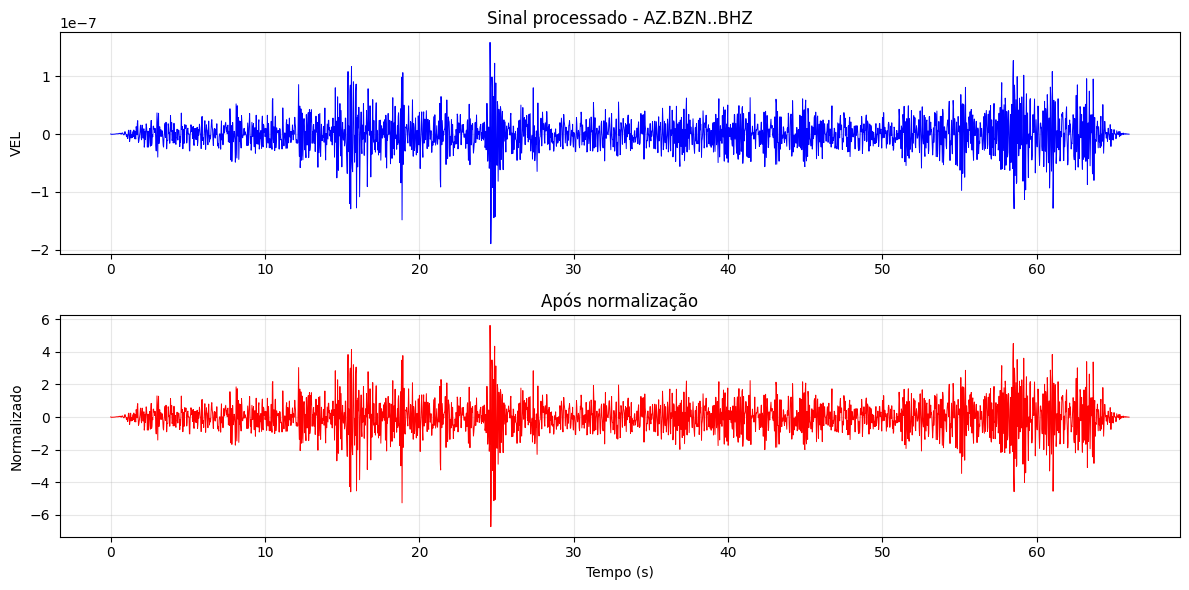

In [26]:
caminho_env = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds"
caminho_wave = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\event_waveforms\2016\2016_001\37509256.ms"
caminho_inv = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\FDSNstationXML\AZ\AZ.BZN.xml"
# Chamada correta: caminho_wave primeiro, depois caminho_inv (inventário)
dados_proc, metadados = preprocessar_waveform(
    caminho_wave,
    caminho_inv,
    canal_alvo='BHZ',
    output='VEL',
    pre_filt=(0.5, 1.0, 18.0, 20.0),
    normalizar=True,
    plot=True
)

In [27]:
# Extrair taxa de amostragem dos metadados
sr = metadados['sampling_rate']  # deve ser 40.0

# Testar diferentes tamanhos de janela
tamanhos = [10, 30, 60]  # segundos

for tam in tamanhos:
    janelas = criar_janelas(dados_proc, sr, tam, sobreposicao=0.5)
    print(f"Janelas de {tam}s: {janelas.shape}  → {janelas.shape[0]} janelas de {janelas.shape[1]} amostras")

Janelas de 10s: (12, 400)  → 12 janelas de 400 amostras
Janelas de 30s: (3, 1200)  → 3 janelas de 1200 amostras
Janelas de 60s: (1, 2400)  → 1 janelas de 2400 amostras


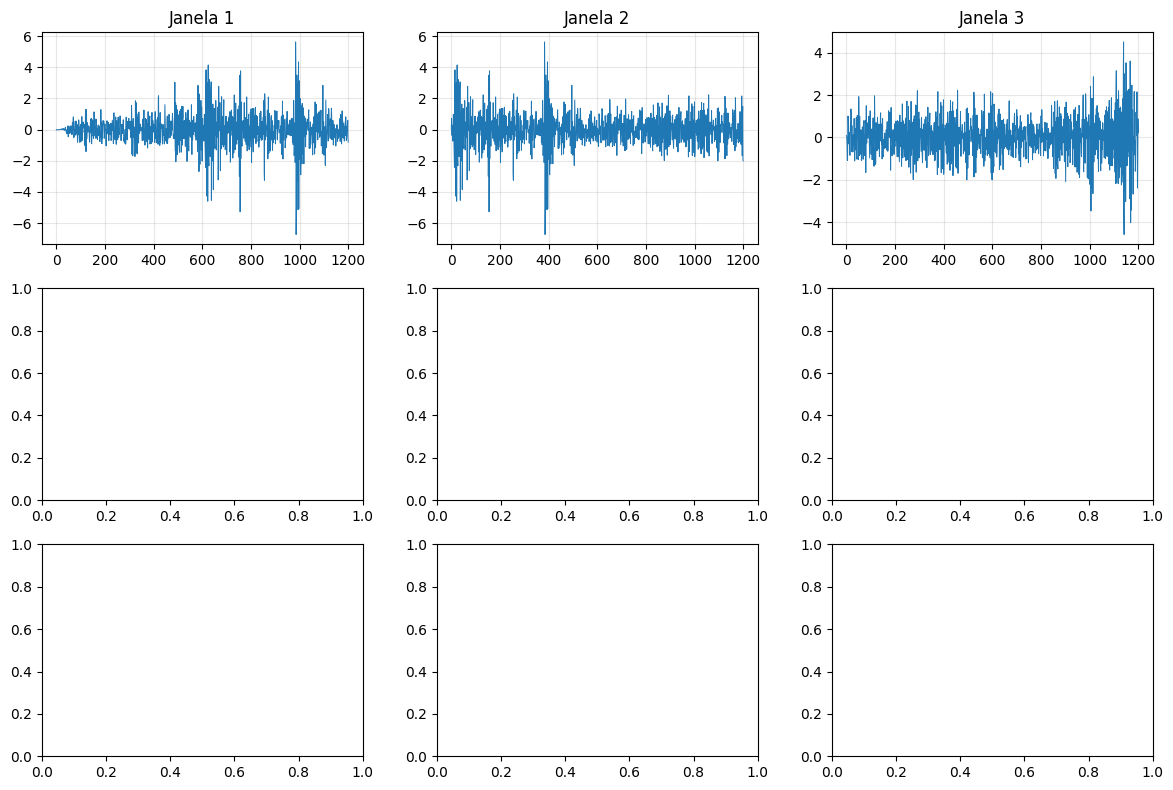

In [ ]:
import matplotlib.pyplot as plt

def plotar_janelas(janelas, n_linhas=3, n_colunas=3):
    fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(12, 8))
    axes = axes.flatten()
    for i in range(min(len(janelas), n_linhas * n_colunas)):
        axes[i].plot(janelas[i], linewidth=0.7)
        axes[i].set_title(f'Janela {i+1}')
        axes[i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.tight_layout()
    plt.show()

# Exemplo com janelas de 30s
janelas_30s = criar_janelas(dados_proc, sr, 30, 0.5)
plotar_janelas(janelas_30s)

In [29]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import os

client = Client("SCEDC")

# Definir período (ex: janeiro de 2016)
start = UTCDateTime("2016-01-01T00:00:00")
end = start + 7 * 86400  # 7 dias depois

# Baixar dados contínuos da estação PASC, canal BHZ
st = client.get_waveforms("CI", "PASC", "*", "BHZ", start, end)

# Salvar em arquivo MiniSEED
st.write("CI.PASC.BHZ.2016-01-01.mseed", format="MSEED")
print(f"Baixado: {len(st)} traces, duração total: {st[0].stats.endtime - st[0].stats.starttime}")

Baixado: 2 traces, duração total: 604799.975


In [ ]:
# Caminhos (ajuste)
caminho_continuo = "CI.PASC.BHZ.2016-01-01.mseed"
caminho_inv = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\FDSNstationXML\CI\CI.PASC.xml"  # precisa ter o XML da estação PASC

# Processar (pode demorar alguns minutos)
dados_continuos, meta_continuos = preprocessar_waveform(
    caminho_continuo, caminho_inv,
    canal_alvo='BHZ', output='VEL',
    pre_filt=(0.5, 1.0, 18.0, 20.0),
    normalizar=True, plot=False
)

# Gerar janelas de treino (ex: 30s, 50% sobreposição)
sr = meta_continuos['sampling_rate']
janelas_treino = criar_janelas(dados_continuos, sr, tamanho_seg=30, sobreposicao=0.5)
print(f"Janelas de treino: {janelas_treino.shape}")